# EDA — Condition Monitoring of Hydraulic Systems

Exploratory analysis of the UCI dataset before any feature engineering or modeling.
Covers: label distributions, stable flag investigation, signal visualization per modality,
label co-occurrence, and sensor correlation.

In [1]:
import sys
from pathlib import Path

# Resolve project root whether notebook is run from notebooks/ or from project root
_cwd = Path().resolve()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from src.data.loader import load_raw
from src.data.labels import load_labels, load_stable_mask, get_label_map

CONFIG = str(PROJECT_ROOT / "configs" / "config.yaml")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 1 — Data loading

In [2]:
sensors = load_raw(CONFIG)
labels  = load_labels(CONFIG)
stable  = load_stable_mask(CONFIG)
label_map = get_label_map(CONFIG)

print(f"\nSensors : {len(sensors)} arrays")
print(f"Labels  : {labels.shape}")
print(f"Stable  : {stable.sum()} / {len(stable)} cycles ({stable.mean():.1%})")

  PS1    loaded: (2205, 6000)


  PS2    loaded: (2205, 6000)


  PS3    loaded: (2205, 6000)


  PS4    loaded: (2205, 6000)


  PS5    loaded: (2205, 6000)


...

  EPS1   loaded: (2205, 6000)


  FS1    loaded: (2205, 600)


  FS2    loaded: (2205, 600)
  TS1    loaded: (2205, 60)
  TS2    loaded: (2205, 60)
  TS3    loaded: (2205, 60)


  TS4    loaded: (2205, 60)
  VS1    loaded: (2205, 60)
  SE     loaded: (2205, 60)
  CE     loaded: (2205, 60)
  CP     loaded: (2205, 60)

All 17 sensors loaded.


Labels loaded: (2205, 4) — {'cooler': 3, 'valve': 4, 'pump': 3, 'accumulator': 4} unique values per component
Stable cycles: 756 / 2205 (34.3%)

Sensors : 17 arrays
Labels  : (2205, 4)
Stable  : 756 / 2205 cycles (34.3%)


## 2 — Label distributions

Class balance per fault component. Imbalanced classes will affect model evaluation choices.

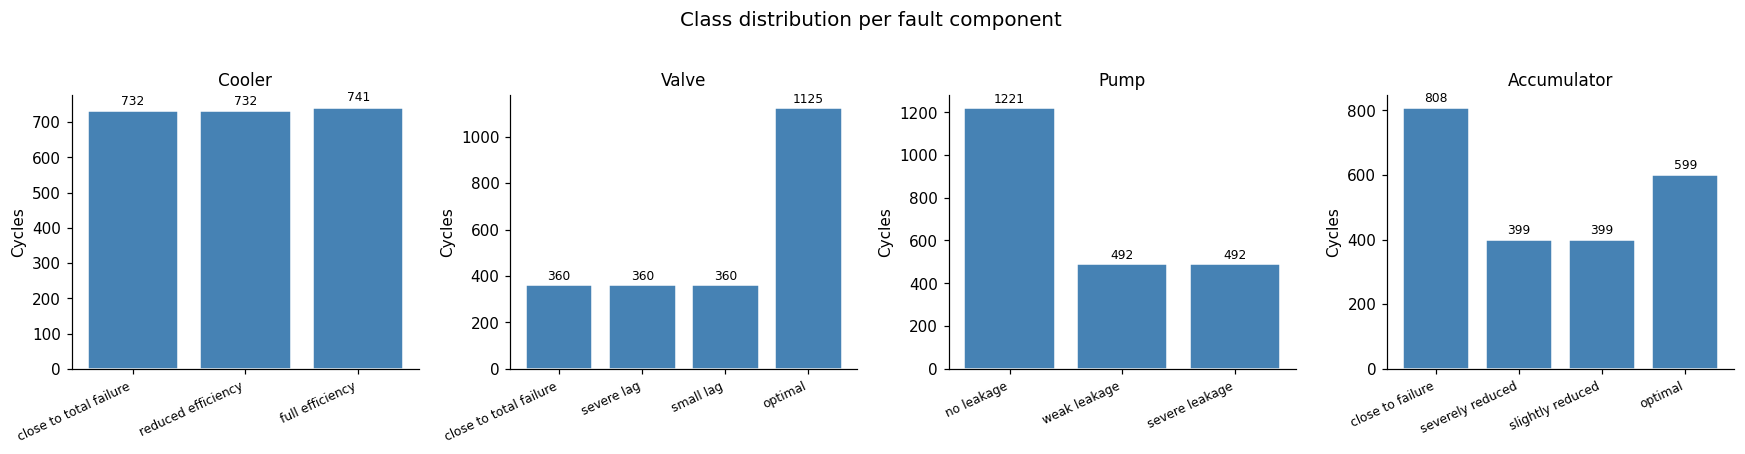

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Class distribution per fault component", fontsize=13, y=1.02)

for ax, component in zip(axes, labels.columns):
    counts = labels[component].value_counts().sort_index()
    readable = {k: v for k, v in label_map[component].items()}
    x_labels = [readable.get(k, str(k)) for k in counts.index]

    bars = ax.bar(range(len(counts)), counts.values, color="steelblue", edgecolor="white")
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(x_labels, rotation=25, ha="right", fontsize=8)
    ax.set_title(component.capitalize(), fontsize=11)
    ax.set_ylabel("Cycles")

    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                str(val), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

## 3 — Stable flag investigation

Only 34.3% of cycles are flagged as stable. We check whether filtering to stable cycles
changes the label distributions significantly — if it does, filtering causes bias.

Stable cycles   : 756
Unstable cycles : 1449



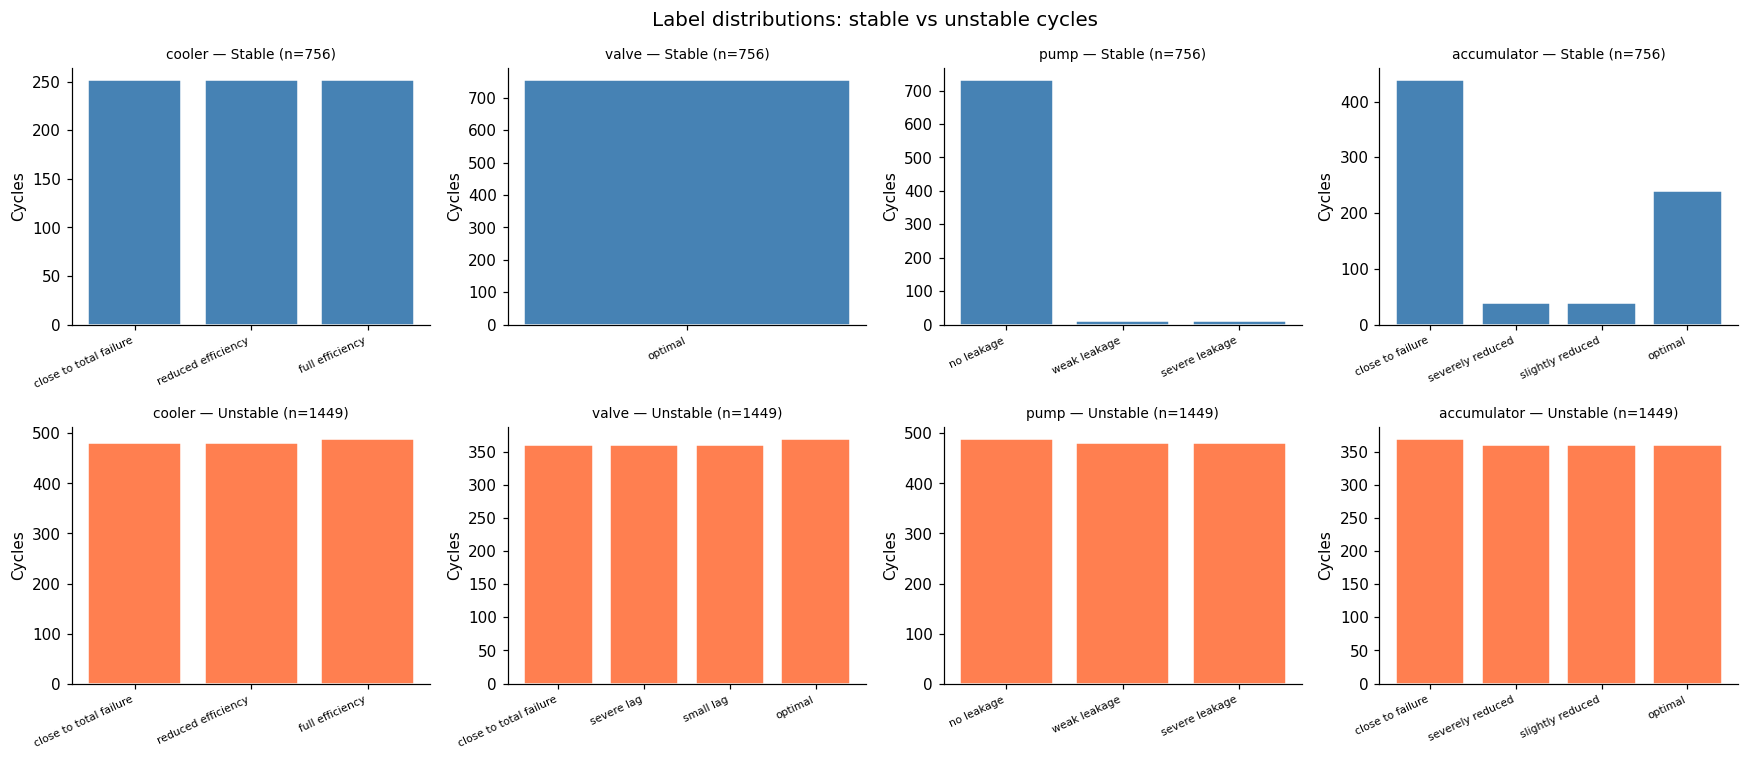

In [4]:
labels_stable   = labels[stable.values]
labels_unstable = labels[~stable.values]

print(f"Stable cycles   : {len(labels_stable)}")
print(f"Unstable cycles : {len(labels_unstable)}")
print()

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle("Label distributions: stable vs unstable cycles", fontsize=13)

for col_idx, component in enumerate(labels.columns):
    for row_idx, (subset, title) in enumerate([
        (labels_stable,   f"Stable (n={len(labels_stable)})"),
        (labels_unstable, f"Unstable (n={len(labels_unstable)})"),
    ]):
        ax = axes[row_idx][col_idx]
        counts = subset[component].value_counts().sort_index()
        readable = label_map[component]
        x_labels = [readable.get(k, str(k)) for k in counts.index]

        color = "steelblue" if row_idx == 0 else "coral"
        ax.bar(range(len(counts)), counts.values, color=color, edgecolor="white")
        ax.set_xticks(range(len(counts)))
        ax.set_xticklabels(x_labels, rotation=25, ha="right", fontsize=7)
        ax.set_title(f"{component} — {title}", fontsize=9)
        ax.set_ylabel("Cycles")

plt.tight_layout()
plt.show()

In [5]:
# Proportion comparison: do distributions shift between stable and unstable?
print("Proportion of each class (stable vs unstable):")
for component in labels.columns:
    props_stable   = labels_stable[component].value_counts(normalize=True).sort_index()
    props_unstable = labels_unstable[component].value_counts(normalize=True).sort_index()
    diff = (props_stable - props_unstable).abs().max()
    print(f"  {component:<15} max proportion difference: {diff:.3f}")

Proportion of each class (stable vs unstable):
  cooler          max proportion difference: 0.004
  valve           max proportion difference: 0.745
  pump            max proportion difference: 0.631
  accumulator     max proportion difference: 0.326


**Decision:** If max proportion difference is < 0.05 for all components → keep all 2205 cycles
and note the stable flag as metadata. If difference is large → filter to stable only and
document the reduction.

## 4 — Signal visualization per modality

One representative sensor per modality. Overlay cycles colored by fault severity
to confirm that different fault states produce visually distinguishable signals.

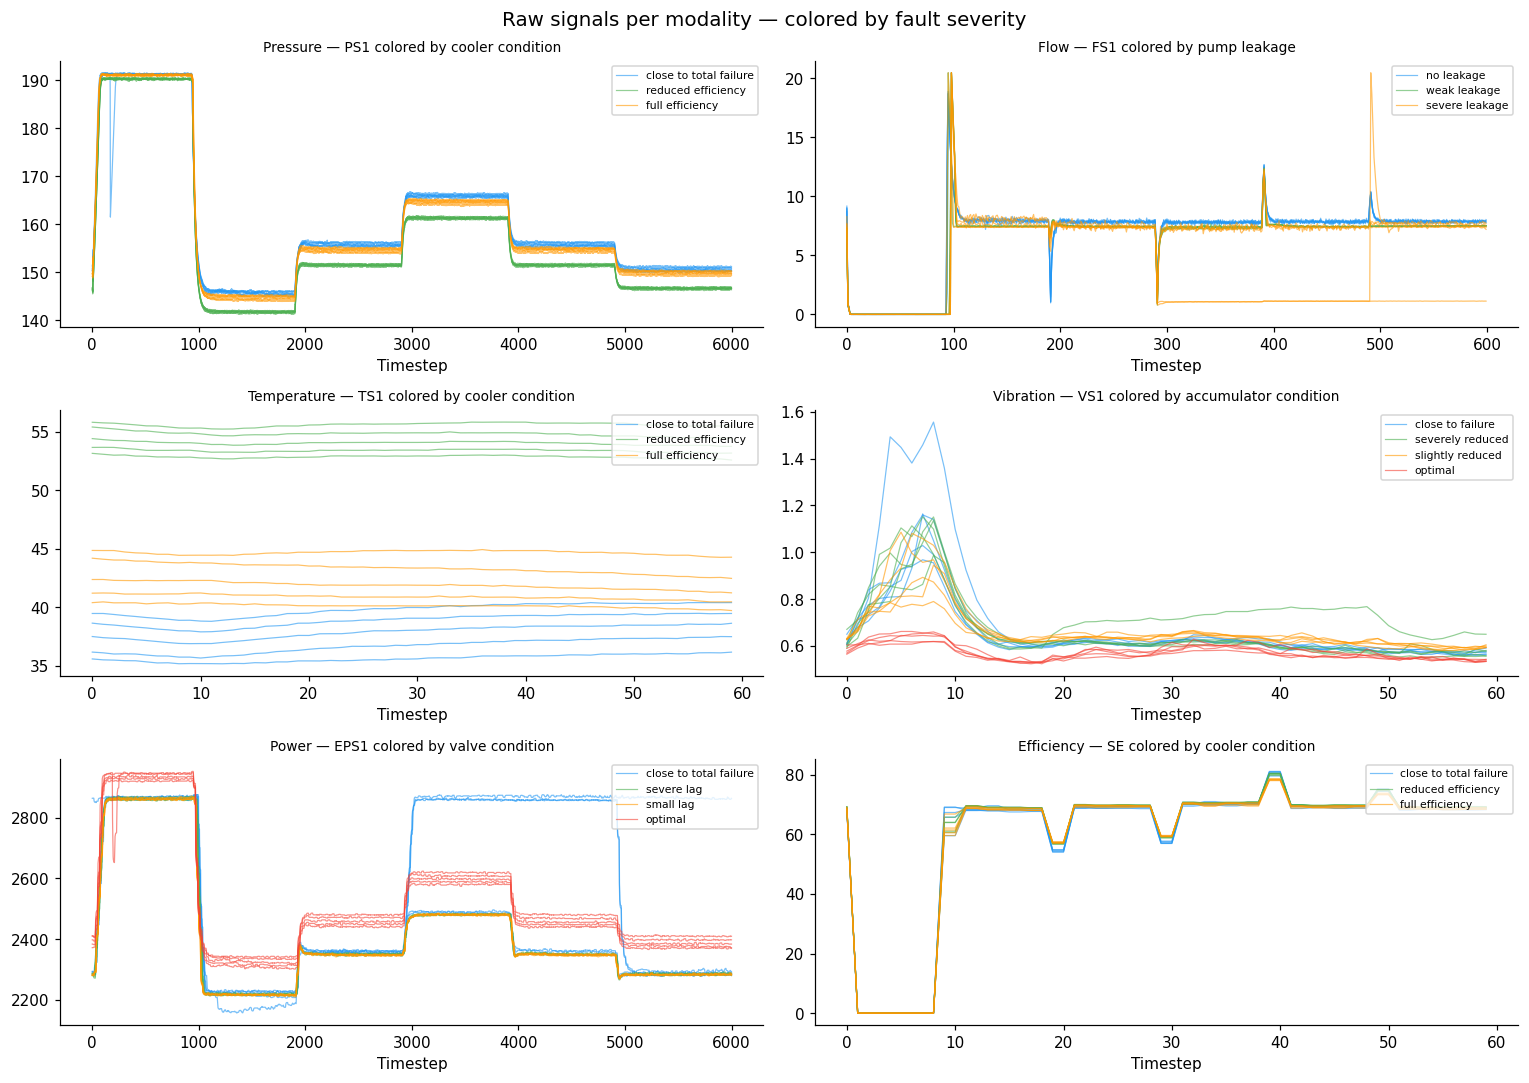

In [6]:
MODALITY_EXAMPLES = [
    ("PS1",  "cooler",      "Pressure — PS1 colored by cooler condition"),
    ("FS1",  "pump",        "Flow — FS1 colored by pump leakage"),
    ("TS1",  "cooler",      "Temperature — TS1 colored by cooler condition"),
    ("VS1",  "accumulator", "Vibration — VS1 colored by accumulator condition"),
    ("EPS1", "valve",       "Power — EPS1 colored by valve condition"),
    ("SE",   "cooler",      "Efficiency — SE colored by cooler condition"),
]

PALETTE = ["#2196F3", "#4CAF50", "#FF9800", "#F44336"]
N_CYCLES_PER_CLASS = 5

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle("Raw signals per modality — colored by fault severity", fontsize=13)

for ax, (sensor, component, title) in zip(axes.flat, MODALITY_EXAMPLES):
    signal = sensors[sensor]       # (2205, n_timesteps)
    fault  = labels[component]     # (2205,)
    classes = sorted(fault.unique())

    for class_idx, cls in enumerate(classes):
        idx = np.where(fault.values == cls)[0][:N_CYCLES_PER_CLASS]
        label_str = label_map[component].get(cls, str(cls))
        color = PALETTE[class_idx % len(PALETTE)]

        for i, cycle_idx in enumerate(idx):
            ax.plot(
                signal[cycle_idx],
                color=color,
                alpha=0.6,
                linewidth=0.8,
                label=label_str if i == 0 else None,
            )

    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Timestep")
    ax.legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.show()

## 5 — Label co-occurrence

How often do fault severities appear together across the 4 components?
Strong co-occurrence motivates Classifier Chains over independent classifiers.

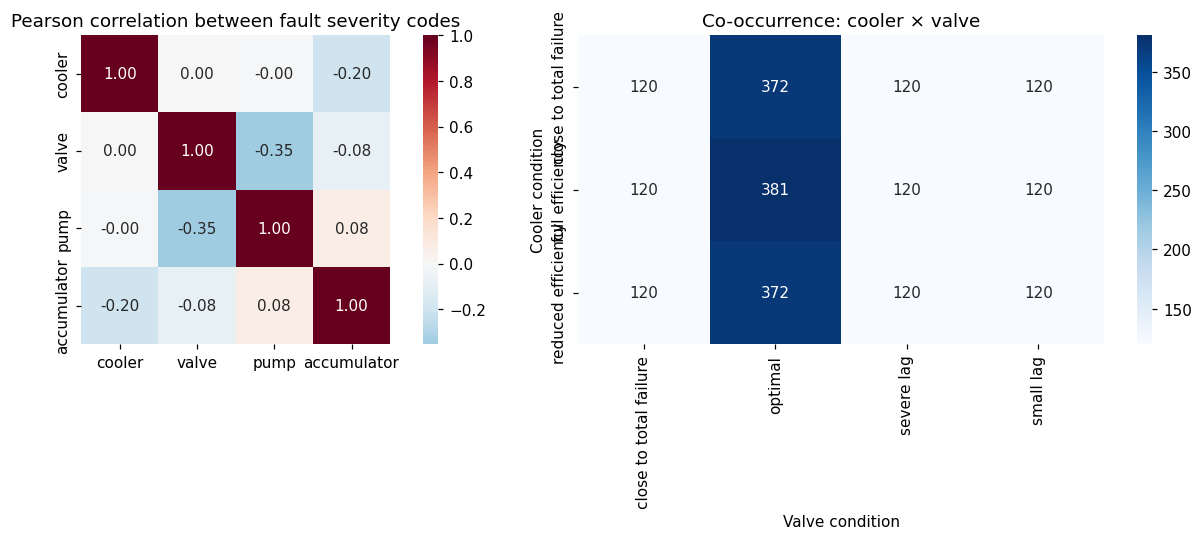

In [7]:
# Pairwise co-occurrence: for each pair of components, correlation of their severity codes
corr_labels = labels.copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: raw correlation between label columns
label_corr = corr_labels.corr()
sns.heatmap(
    label_corr, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, ax=axes[0], square=True,
    xticklabels=labels.columns, yticklabels=labels.columns
)
axes[0].set_title("Pearson correlation between fault severity codes")

# Right: co-occurrence count matrix (cooler vs valve as example pair)
co = pd.crosstab(
    labels["cooler"].map(label_map["cooler"]),
    labels["valve"].map(label_map["valve"]),
)
sns.heatmap(co, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Co-occurrence: cooler × valve")
axes[1].set_xlabel("Valve condition")
axes[1].set_ylabel("Cooler condition")

plt.tight_layout()
plt.show()

## 6 — Sensor correlation

Pearson correlation across all 17 sensors using per-cycle mean as a simple aggregation.
Reveals redundancy within modality groups and cross-modality coupling.

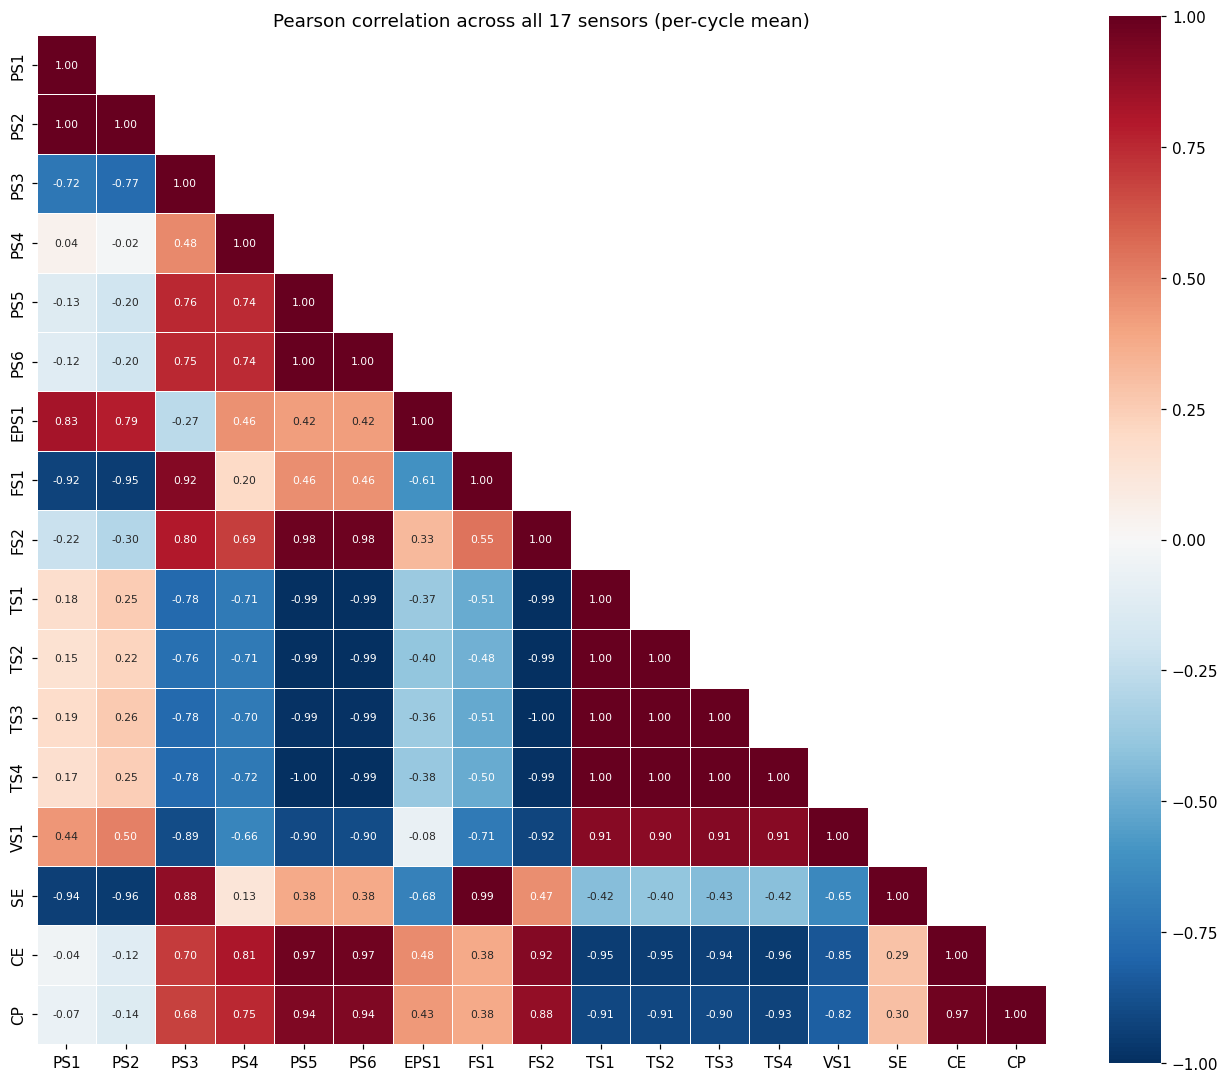

In [8]:
# Per-cycle mean for each sensor → (2205, 17) DataFrame
sensor_means = pd.DataFrame(
    {name: arr.mean(axis=1) for name, arr in sensors.items()}
)

corr = sensor_means.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # show lower triangle only

sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.4, ax=ax,
    annot_kws={"size": 7}
)
ax.set_title("Pearson correlation across all 17 sensors (per-cycle mean)", fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
# Highlight the strongest cross-modality correlations
corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["sensor_a", "sensor_b", "correlation"]
corr_pairs["abs_corr"] = corr_pairs["correlation"].abs()

print("Top 10 strongest sensor correlations:")
print(corr_pairs.sort_values("abs_corr", ascending=False).head(10).to_string(index=False))

Top 10 strongest sensor correlations:
sensor_a sensor_b  correlation  abs_corr
     PS6      PS5     0.999993  0.999993
     TS3      TS1     0.999732  0.999732
     TS2      TS1     0.999344  0.999344
     TS4      TS1     0.999242  0.999242
     TS3      TS2     0.999067  0.999067
     TS4      TS3     0.998395  0.998395
     TS4      TS2     0.998292  0.998292
     TS3      FS2    -0.996281  0.996281
     PS2      PS1     0.995294  0.995294
     TS4      PS5    -0.995100  0.995100
